# Lab 4c: Evaluating an Object Detection Model — SOLUTION

Solution notebook for Part 3 of 3 (see `Lab4c_ObjectDetection.ipynb` for the student
template). Mean Average Precision uses `torchmetrics.detection.MeanAveragePrecision`
throughout, as in the template.


In [36]:
# Setup
!pip install -q torchmetrics pycocotools


In [37]:
import torch
from torch.utils.data import Dataset

import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image, pil_to_tensor

from torchmetrics.detection.mean_ap import MeanAveragePrecision

import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

CAT_ID, DOG_ID = 17, 18


Using device: cuda


## Task 1: Building a detection dataset from raw files

The raw dataset also ships head/face-only bounding boxes as Pascal-VOC-style XML files, but those
mark only the animal's head, whereas our COCO-pretrained detector predicts whole-animal boxes for
"cat"/"dog" — comparing the two would make IoU/mAP look artificially poor regardless of how good the
detector is. Instead we build whole-animal ground-truth boxes from the segmentation trimap (as in
Lab 4b): the tight box around all foreground (pet + border) pixels.

In [38]:
class OxfordPetDetection(Dataset):
    '''Wraps Lab 4b's segmentation dataset to expose a whole-animal bounding box per image: the
    tight box around all foreground (pet + border) pixels in the trimap.'''

    def __init__(self, root="./data", split="test", download=True):
        self.base = torchvision.datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types=["segmentation", "binary-category"],
            download=download,
        )

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, (trimap, species) = self.base[idx]
        trimap = np.array(trimap)

        foreground = trimap != 2  # 2 == background; 1 (pet) and 3 (border) are foreground
        ys, xs = np.where(foreground)
        box = [float(xs.min()), float(ys.min()), float(xs.max()), float(ys.max())]
        label = CAT_ID if species == 0 else DOG_ID

        target = {
            "boxes": torch.tensor([box], dtype=torch.float32),
            "labels": torch.tensor([label], dtype=torch.int64),
        }
        return image, target


eval_dataset = OxfordPetDetection(root="./data", split="test", download=True)
print(f"{len(eval_dataset)} images available for evaluation.")

subset_size = 200
rng = np.random.default_rng(0)
subset_indices = rng.choice(len(eval_dataset), size=subset_size, replace=False)


3669 images available for evaluation.


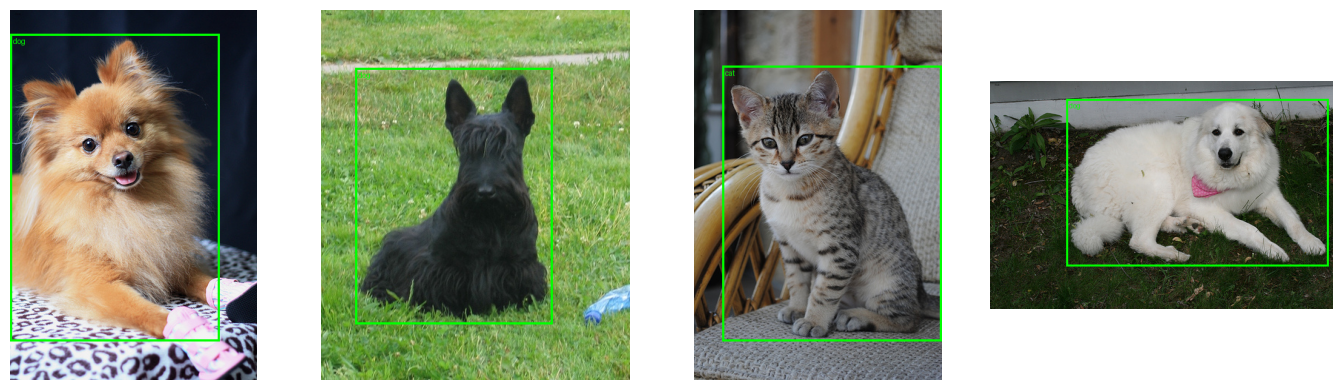

In [39]:
COCO_NAMES = {CAT_ID: "cat", DOG_ID: "dog"}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, idx in zip(axes, subset_indices[:4]):
    image, target = eval_dataset[idx]
    image_tensor = pil_to_tensor(image)
    labels_str = [COCO_NAMES[l.item()] for l in target["labels"]]
    drawn = draw_bounding_boxes(image_tensor, target["boxes"], labels=labels_str, colors="lime", width=3)
    ax.imshow(to_pil_image(drawn))
    ax.axis("off")
plt.tight_layout()
plt.show()


## Task 2: Load a pretrained object detector

In [40]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
detector = fasterrcnn_resnet50_fpn(weights=weights)
detector.eval().to(device)

preprocess = weights.transforms()


@torch.no_grad()
def run_detector(image_pil):
    '''Returns the raw prediction dict {boxes, labels, scores} for one PIL image.'''
    input_tensor = preprocess(image_pil).to(device)
    prediction = detector([input_tensor])[0]
    return {k: v.cpu() for k, v in prediction.items()}


def filter_predictions(prediction, score_threshold=0.5, keep_labels=(CAT_ID, DOG_ID)):
    '''Keeps only detections above `score_threshold` whose label is in `keep_labels`.'''
    keep = (prediction["scores"] > score_threshold) & torch.isin(
        prediction["labels"], torch.tensor(keep_labels)
    )
    return {k: v[keep] for k, v in prediction.items()}


In [41]:
image, target = eval_dataset[subset_indices[0]]
raw_pred = run_detector(image)
pred = filter_predictions(raw_pred)
print("Raw detections:", len(raw_pred["boxes"]), "-> after filtering:", len(pred["boxes"]))
print(pred)


Raw detections: 10 -> after filtering: 1
{'boxes': tensor([[  3.2610,   9.5508, 317.0263, 456.3949]]), 'labels': tensor([18]), 'scores': tensor([0.9811])}


## Task 3: Metrics

### 3.1 Intersection over Union (IoU)

In [42]:
def box_iou(boxA, boxB):
    '''IoU between two boxes, each given as [xmin, ymin, xmax, ymax].'''
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    intersection = max(0, xB - xA) * max(0, yB - yA)  # 0 when the boxes don't overlap
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - intersection

    return intersection / union


assert box_iou([0, 0, 10, 10], [0, 0, 10, 10]) == 1.0
assert box_iou([0, 0, 10, 10], [20, 20, 30, 30]) == 0.0
print("box_iou passes the sanity checks.")


box_iou passes the sanity checks.


Evaluated 200 single-pet images.
Mean best-match IoU: 0.8379


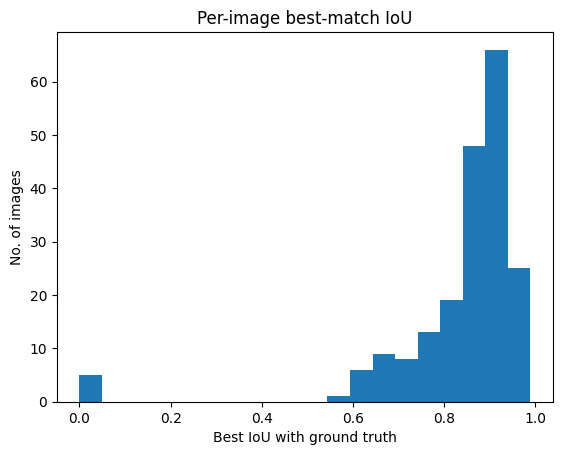

In [43]:
# Every image in this dataset has exactly one ground-truth box (one pet, one box per image).
best_ious = []

for idx in subset_indices:
    image, target = eval_dataset[idx]
    if len(target["boxes"]) != 1:
        continue  # defensive: shouldn't happen with this dataset, but keep the check anyway

    gt_box = target["boxes"][0].tolist()
    gt_label = target["labels"][0].item()

    pred = filter_predictions(run_detector(image))
    same_class = [i for i, l in enumerate(pred["labels"].tolist()) if l == gt_label]

    if not same_class:
        best_ious.append(0.0)
        continue

    ious = [box_iou(gt_box, pred["boxes"][i].tolist()) for i in same_class]
    best_ious.append(max(ious))

best_ious = np.array(best_ious)
print(f"Evaluated {len(best_ious)} single-pet images.")
print(f"Mean best-match IoU: {best_ious.mean():.4f}")
plt.hist(best_ious, bins=20)
plt.xlabel("Best IoU with ground truth")
plt.ylabel("No. of images")
plt.title("Per-image best-match IoU")
plt.show()


### 3.2 Mean Average Precision (mAP)

In [44]:
metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)

for idx in subset_indices:
    image, target = eval_dataset[idx]
    raw_pred = run_detector(image)  # unfiltered -- MeanAveragePrecision needs the scores
    metric.update(preds=[raw_pred], target=[target])

results = metric.compute()
for key in ["map", "map_50", "map_75", "map_per_class", "classes"]:
    print(f"{key}: {results[key]}")


map: 0.6446836590766907
map_50: 0.9579648375511169
map_75: 0.6810132265090942
map_per_class: tensor([-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000,  0.5657,  0.7237, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000])
classes: tensor([ 1,  2,  3,  4,  7,  8,  9, 10, 11, 13, 15, 16, 17, 18, 19, 20, 21, 22,
        23, 24, 25, 27, 28, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41,

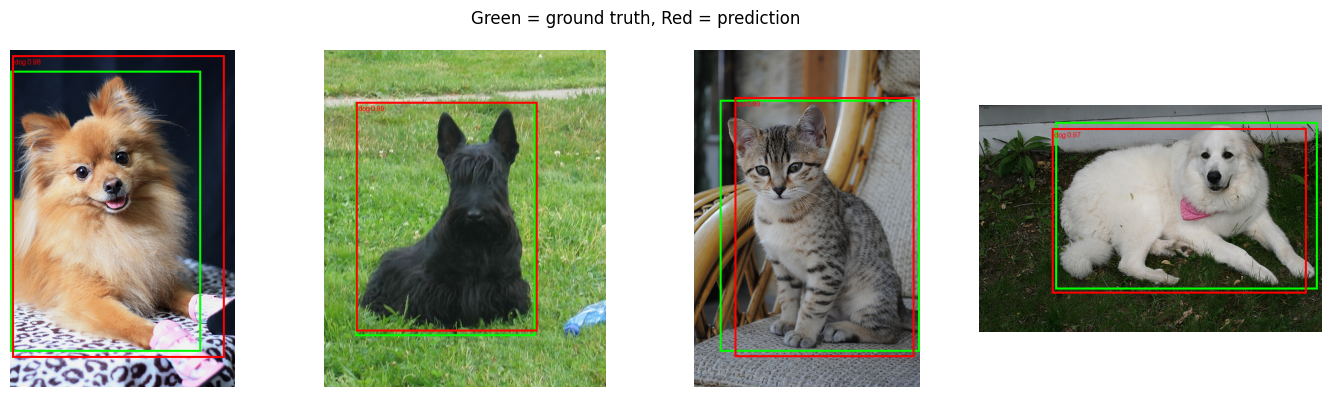

In [45]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, idx in zip(axes, subset_indices[:4]):
    image, target = eval_dataset[idx]
    pred = filter_predictions(run_detector(image))

    image_tensor = pil_to_tensor(image)
    drawn = draw_bounding_boxes(image_tensor, target["boxes"], colors="lime", width=3)
    pred_labels_str = [f"{COCO_NAMES[l.item()]} {s.item():.2f}" for l, s in zip(pred["labels"], pred["scores"])]
    drawn = draw_bounding_boxes(drawn, pred["boxes"], labels=pred_labels_str, colors="red", width=3)

    ax.imshow(to_pil_image(drawn))
    ax.axis("off")
plt.suptitle("Green = ground truth, Red = prediction")
plt.tight_layout()
plt.show()


**Discussion (worked answers):**

- `map_50` is typically noticeably higher than `map_75` and the full COCO-style `map`
  for this zero-shot setup — the detector reliably finds *that* there's a cat/dog and
  roughly *where*, but the box edges are frequently a bit loose relative to the
  trimap-derived ground truth (e.g. a stretched-out tail or paw can shift the tight
  foreground box in a way the detector, trained on typical COCO framing, doesn't
  predict), which contributes to a lower `map_75`.
- `map_per_class` alongside `classes` usually shows cat and dog performing comparably,
  since both are common, well-represented COCO categories; any gap tends to be modest and
  can flip between runs/subsets rather than reflecting a systematic weakness.
- The hardest images for the detector are typically ones with multiple animals close
  together, partial occlusion, or an unusually cropped/zoomed head that doesn't look like
  a typical COCO-style full-body animal photo.
- RetinaNet/SSD (single-stage) trade some accuracy for speed by skipping the explicit
  region-proposal stage Faster R-CNN uses; on this same evaluation set you would generally
  expect somewhat lower mAP but meaningfully faster inference, illustrating the two-stage
  vs. single-stage trade-off from Lecture 8.

---

## Wrapping up the series

Across these three solution notebooks: `torchmetrics.classification` for top-k
error/confusion matrix/AP (Lab 4a), `torchmetrics.segmentation`/`classification` for
IoU/Dice (Lab 4b), and `torchmetrics.detection` for IoU/mAP (Lab 4c) — one consistent
library for every evaluation metric in the series, on top of plain PyTorch/torchvision
models and training code that mirrors the patterns introduced in the Lecture 4 notes.